# Task XI: Parameterized Quantum Circuit (PQC) Embedding


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

### Objective

Train a classical neural network to predict PQC parameters that prepare target quantum states. Given an input vector $\mathbf{x} \in \mathbb{R}^d$, the MLP produces rotation angles $\boldsymbol{\theta} = f(\mathbf{x})$, which are fed into a parameterized quantum circuit to produce $|\psi(\boldsymbol{\theta})\rangle$. The training objective minimizes the MSE between the predicted state vector and a target state $|\phi(\mathbf{x})\rangle$ generated by a fixed teacher circuit.

### Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | Setup | Dependencies and configuration |
| 2 | Data Generation | Normally distributed inputs + teacher circuit targets |
| 3 | Neural Network | MLP for PQC parameter estimation |
| 4 | Quantum Circuit | PQC with RY, CNOT, RZ layers |
| 5 | Training | MSE loss optimization with Adam |
| 6 | Evaluation | Fidelity analysis and state visualization |

---

## 1. Setup

In [1]:
# Install dependencies (uncomment if needed)
# !pip install pennylane torch matplotlib

import pennylane as qml
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# Configuration
INPUT_DIM = 8        # Input vector dimension
N_QUBITS = 4         # Number of qubits in the PQC
N_LAYERS = 2          # Layers in the PQC (RY + CNOT + RZ per layer)
N_PARAMS = N_QUBITS * N_LAYERS * 2  # RY + RZ per qubit per layer = 16
N_SAMPLES = 1000
BATCH_SIZE = 64
N_EPOCHS = 80
LR = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PennyLane {qml.__version__} | PyTorch {torch.__version__}")
print(f"Qubits: {N_QUBITS} | PQC params: {N_PARAMS} | State dim: {2**N_QUBITS}")
print(f"Device: {device}")

PennyLane 0.44.1 | PyTorch 2.11.0
Qubits: 4 | PQC params: 16 | State dim: 16
Device: cpu


---

## 2. Data Generation

I sample 1000 input vectors from $\mathcal{N}(0, I_8)$. For each input, a **teacher circuit** (a fixed PQC with frozen random parameters combined with input-dependent encoding) produces a target quantum state. The teacher uses angle embedding followed by a fixed random ansatz, ensuring each input maps to a unique target state.

### 2.1 Teacher Circuit

The teacher circuit encodes the input vector into rotation angles and applies a fixed entangling ansatz:

1. **Angle embedding**: first $N_\text{qubits}$ components of $\mathbf{x}$ → $RY$ rotations
2. **Fixed ansatz**: two layers of $RY$–CNOT–$RZ$ with frozen random parameters

This produces input-dependent target states $|\phi(\mathbf{x})\rangle$ that the student network must learn to reproduce.

In [2]:
# Fixed teacher parameters (frozen — never updated)
teacher_params = np.random.uniform(0, 2 * np.pi, size=N_PARAMS)

dev_teacher = qml.device("default.qubit", wires=N_QUBITS)


def pqc_ansatz(params, n_qubits, n_layers):
    """Shared PQC ansatz: RY → CNOT ring → RZ per layer."""
    idx = 0
    for layer in range(n_layers):
        # RY rotations
        for q in range(n_qubits):
            qml.RY(params[idx], wires=q)
            idx += 1
        # CNOT entanglement ring
        for q in range(n_qubits):
            qml.CNOT(wires=[q, (q + 1) % n_qubits])
        # RZ rotations
        for q in range(n_qubits):
            qml.RZ(params[idx], wires=q)
            idx += 1


@qml.qnode(dev_teacher, interface="numpy")
def teacher_circuit(x):
    """Teacher: angle-embed input → fixed random ansatz → state vector."""
    # Encode input into qubits
    for q in range(N_QUBITS):
        qml.RY(x[q], wires=q)
    # Fixed ansatz
    pqc_ansatz(teacher_params, N_QUBITS, N_LAYERS)
    return qml.state()


print("Teacher circuit:")
print(qml.draw(teacher_circuit)(np.zeros(N_QUBITS)))

Teacher circuit:
0: ──RY(0.00)──RY(2.35)─╭●───────╭X──RZ(0.98)──RY(3.78)─╭●───────╭X──RZ(5.23)─┤  State
1: ──RY(0.00)──RY(5.97)─╰X─╭●────│───RZ(0.98)──RY(4.45)─╰X─╭●────│───RZ(1.33)─┤  State
2: ──RY(0.00)──RY(4.60)────╰X─╭●─│───RZ(0.36)──RY(0.13)────╰X─╭●─│───RZ(1.14)─┤  State
3: ──RY(0.00)──RY(3.76)───────╰X─╰●──RZ(5.44)──RY(6.09)───────╰X─╰●──RZ(1.15)─┤  State


### 2.2 Dataset Construction

In [3]:
# Sample inputs from N(0, 1)
X = np.random.randn(N_SAMPLES, INPUT_DIM).astype(np.float32)

# Generate target states using teacher circuit
print("Generating target quantum states...")
target_states = []
for i in range(N_SAMPLES):
    state = teacher_circuit(X[i, :N_QUBITS])
    # Store as [real, imag] interleaved for real-valued MSE loss
    state_ri = np.concatenate([state.real, state.imag])
    target_states.append(state_ri)
    if (i + 1) % 250 == 0:
        print(f"  {i + 1}/{N_SAMPLES} states generated")

Y = np.array(target_states, dtype=np.float32)

# Train/test split (80/20)
n_train = 800
X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(Y_test))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

state_dim = 2 ** N_QUBITS
print(f"\nDataset: {n_train} train / {N_SAMPLES - n_train} test")
print(f"Input shape: {X_train.shape} | Target shape: {Y_train.shape}")
print(f"Target: {state_dim} complex amplitudes → {2 * state_dim} real values (re/im)")

Generating target quantum states...
  250/1000 states generated
  500/1000 states generated
  750/1000 states generated
  1000/1000 states generated

Dataset: 800 train / 200 test
Input shape: (800, 8) | Target shape: (800, 32)
Target: 16 complex amplitudes → 32 real values (re/im)


---

## 3. Neural Network for PQC Parameter Estimation

A 3-layer MLP maps $\mathbf{x} \in \mathbb{R}^8 \to \boldsymbol{\theta} \in \mathbb{R}^{16}$ (the PQC rotation angles).

| Layer | Shape | Activation |
|-------|-------|------------|
| Linear 1 | 8 → 64 | ReLU |
| Linear 2 | 64 → 64 | ReLU |
| Linear 3 | 64 → 16 | — |

In [4]:
class ParameterEstimator(nn.Module):
    """MLP that maps input data to PQC rotation parameters."""

    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, n_params=N_PARAMS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_params),
        )

    def forward(self, x):
        return self.net(x)


model = ParameterEstimator().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"ParameterEstimator: {total_params:,} trainable parameters")
print(model)

ParameterEstimator: 5,776 trainable parameters
ParameterEstimator(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
)


---

## 4. Quantum Circuit (Student PQC)

The student PQC uses the **same ansatz** as the teacher but receives its parameters from the MLP rather than from a fixed set. This means the student must learn to produce parameters that, when combined with no input encoding, replicate the teacher's input-dependent output.

The student circuit applies the MLP-predicted parameters directly (no angle embedding step), so the MLP must internalize both the input encoding and the fixed teacher ansatz.

In [5]:
dev_student = qml.device("default.qubit", wires=N_QUBITS)


@qml.qnode(dev_student, interface="torch", diff_method="backprop")
def student_circuit(params):
    """Student PQC: MLP-predicted params → quantum state."""
    pqc_ansatz(params, N_QUBITS, N_LAYERS)
    return qml.state()


# Verify circuit
test_params = torch.randn(N_PARAMS)
test_state = student_circuit(test_params)
print(f"Student output: {test_state.shape[0]} complex amplitudes")
print(f"Norm check: {torch.sum(torch.abs(test_state)**2).item():.6f}")
print(f"\nStudent circuit diagram:")
print(qml.draw(student_circuit)(test_params))

Student output: 16 complex amplitudes
Norm check: 1.000000

Student circuit diagram:
0: ──RY(-1.11)─╭●───────╭X──RZ(0.10)───RY(0.73)──╭●───────╭X──RZ(-0.27)─┤  State
1: ──RY(-0.15)─╰X─╭●────│───RZ(0.31)───RY(1.44)──╰X─╭●────│───RZ(0.02)──┤  State
2: ──RY(-2.25)────╰X─╭●─│───RZ(0.19)───RY(-1.44)────╰X─╭●─│───RZ(1.28)──┤  State
3: ──RY(0.40)────────╰X─╰●──RZ(-0.40)──RY(0.52)────────╰X─╰●──RZ(-0.31)─┤  State


---

## 5. Training

### Pipeline

For each batch:
1. MLP predicts PQC parameters: $\boldsymbol{\theta}_i = f_\text{MLP}(\mathbf{x}_i)$
2. Student PQC produces state: $|\psi(\boldsymbol{\theta}_i)\rangle$
3. State is split into real/imaginary parts for MSE comparison
4. Loss: $\mathcal{L} = \text{MSE}\bigl([\text{Re}(\psi), \text{Im}(\psi)],\; [\text{Re}(\phi), \text{Im}(\phi)]\bigr)$

The gradients flow through the PQC (via backprop on `default.qubit`) into the MLP parameters.

In [6]:
def get_student_state_vector(params_batch):
    """Run student PQC for each sample; return real/imag concatenated vectors."""
    states = []
    for params in params_batch:
        state = student_circuit(params)
        # Concatenate real and imaginary parts
        state_ri = torch.cat([state.real, state.imag])
        states.append(state_ri)
    return torch.stack(states).float()  # PennyLane returns float64; match target dtype


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []
test_losses = []

print(f"Training for {N_EPOCHS} epochs | Optimizer: Adam (lr={LR})")
print(f"Loss: MSE on state vectors (real/imag representation)")
print("-" * 55)

for epoch in range(N_EPOCHS):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    n_batches = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # MLP → PQC parameters
        predicted_params = model(x_batch)

        # PQC → state vectors
        predicted_states = get_student_state_vector(predicted_params)

        loss = criterion(predicted_states, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # --- Evaluate ---
    model.eval()
    test_loss = 0.0
    n_test = 0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predicted_params = model(x_batch)
            predicted_states = get_student_state_vector(predicted_params)
            test_loss += criterion(predicted_states, y_batch).item()
            n_test += 1
    avg_test_loss = test_loss / n_test
    test_losses.append(avg_test_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  |  Train MSE: {avg_train_loss:.6f}  |  Test MSE: {avg_test_loss:.6f}")

print("-" * 55)
print(f"Final  |  Train MSE: {train_losses[-1]:.6f}  |  Test MSE: {test_losses[-1]:.6f}")

Training for 80 epochs | Optimizer: Adam (lr=0.001)
Loss: MSE on state vectors (real/imag representation)
-------------------------------------------------------
Epoch   1/80  |  Train MSE: 0.063054  |  Test MSE: 0.058936
Epoch  10/80  |  Train MSE: 0.007436  |  Test MSE: 0.006604
Epoch  20/80  |  Train MSE: 0.000598  |  Test MSE: 0.000818
Epoch  30/80  |  Train MSE: 0.000257  |  Test MSE: 0.000403
Epoch  40/80  |  Train MSE: 0.000168  |  Test MSE: 0.000290
Epoch  50/80  |  Train MSE: 0.000130  |  Test MSE: 0.000228
Epoch  60/80  |  Train MSE: 0.000100  |  Test MSE: 0.000193
Epoch  70/80  |  Train MSE: 0.000083  |  Test MSE: 0.000167
Epoch  80/80  |  Train MSE: 0.000068  |  Test MSE: 0.000146
-------------------------------------------------------
Final  |  Train MSE: 0.000068  |  Test MSE: 0.000146


### 5.1 Loss Curve

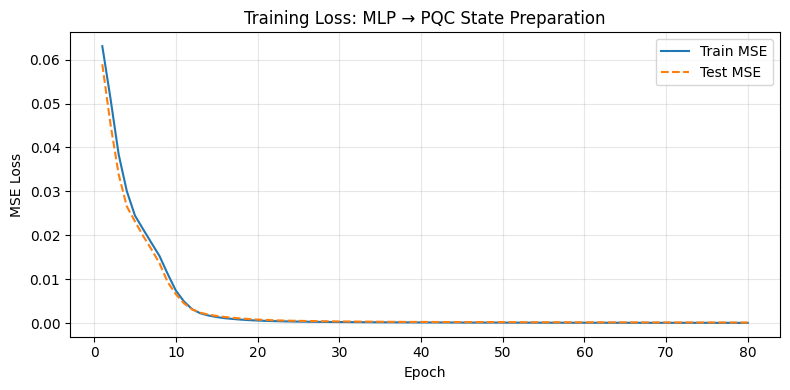

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_EPOCHS + 1), train_losses, label="Train MSE", linewidth=1.5)
ax.plot(range(1, N_EPOCHS + 1), test_losses, label="Test MSE", linewidth=1.5, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training Loss: MLP → PQC State Preparation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 6. Evaluation

### 6.1 Fidelity Computation

State fidelity between predicted and target states:

$$F(\psi, \phi) = |\langle \psi | \phi \rangle|^2$$

I compute this for all test samples by reconstructing complex state vectors from the real/imaginary representation.

In [8]:
model.eval()
state_dim = 2 ** N_QUBITS

fidelities = []
pred_states_complex = []
target_states_complex = []

with torch.no_grad():
    X_test_t = torch.tensor(X_test).to(device)
    Y_test_t = torch.tensor(Y_test)

    predicted_params = model(X_test_t)

    for i in range(len(X_test)):
        # Get predicted state
        pred_state = student_circuit(predicted_params[i])
        pred_np = pred_state.detach().cpu().numpy()

        # Reconstruct target complex state
        target_ri = Y_test[i]
        target_np = target_ri[:state_dim] + 1j * target_ri[state_dim:]

        # Fidelity
        fid = np.abs(np.vdot(pred_np, target_np)) ** 2
        fidelities.append(fid)
        pred_states_complex.append(pred_np)
        target_states_complex.append(target_np)

fidelities = np.array(fidelities)

print(f"Test set fidelity statistics (N={len(fidelities)}):")
print(f"  Mean fidelity:   {fidelities.mean():.4f}")
print(f"  Median fidelity: {np.median(fidelities):.4f}")
print(f"  Min fidelity:    {fidelities.min():.4f}")
print(f"  Max fidelity:    {fidelities.max():.4f}")
print(f"  Std:             {fidelities.std():.4f}")

Test set fidelity statistics (N=200):
  Mean fidelity:   0.9951
  Median fidelity: 0.9975
  Min fidelity:    0.9443
  Max fidelity:    0.9996
  Std:             0.0080


### 6.2 Fidelity Distribution

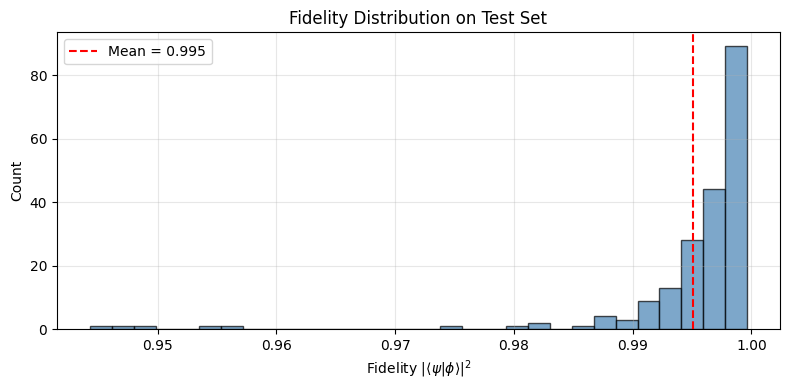

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fidelities, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(fidelities.mean(), color="red", linestyle="--", label=f"Mean = {fidelities.mean():.3f}")
ax.set_xlabel("Fidelity $|\\langle\\psi|\\phi\\rangle|^2$")
ax.set_ylabel("Count")
ax.set_title("Fidelity Distribution on Test Set")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 State Vector Visualization

Compare predicted vs target state amplitudes for a few test samples. Each bar chart shows the probability distribution $|\alpha_k|^2$ over the $2^4 = 16$ computational basis states.

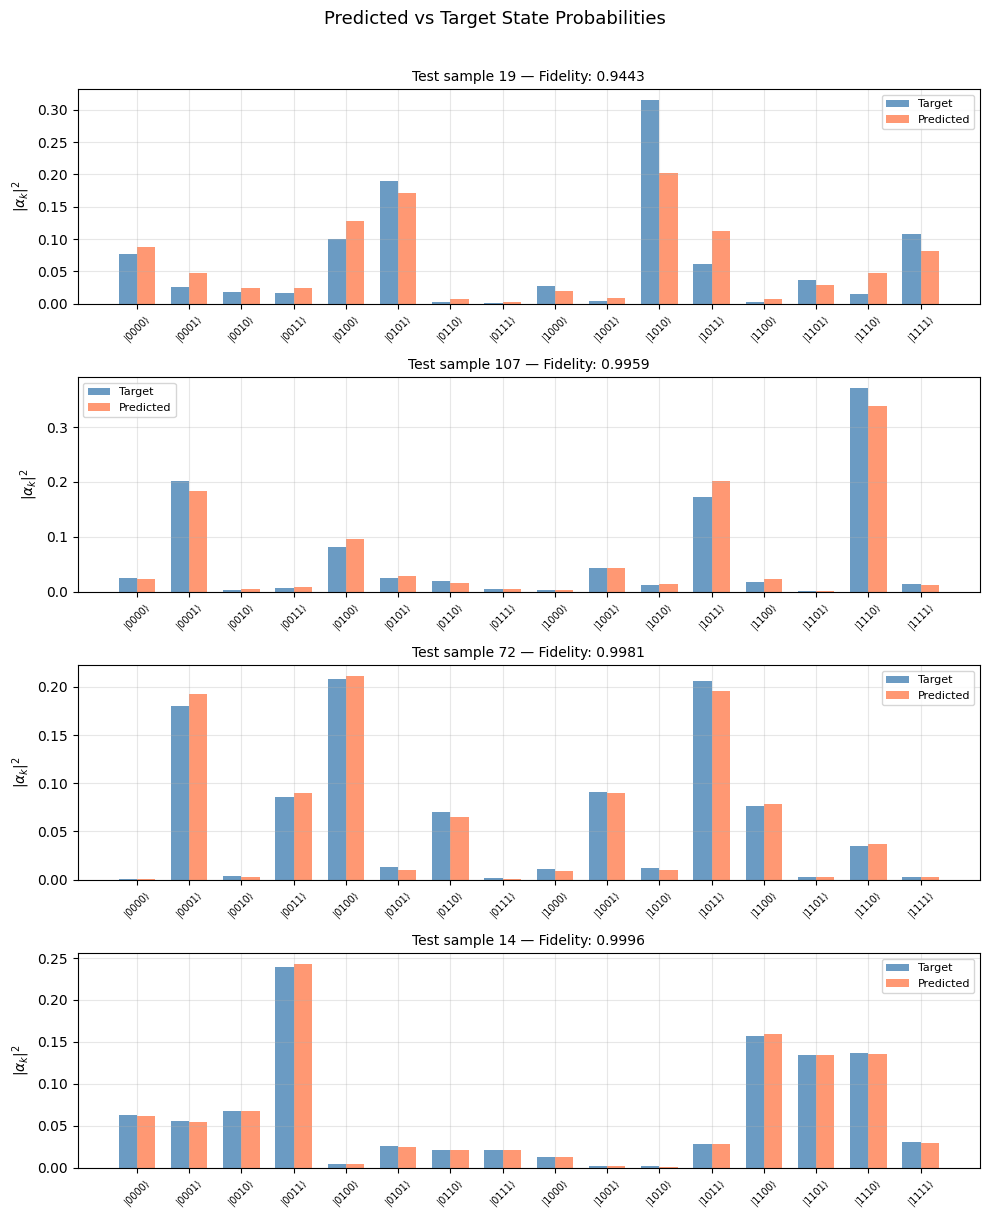

In [10]:
n_show = 4
basis_labels = [f"|{i:04b}⟩" for i in range(state_dim)]

fig, axes = plt.subplots(n_show, 1, figsize=(10, 3 * n_show))

# Pick samples spread across the fidelity range
sorted_idx = np.argsort(fidelities)
show_indices = [
    sorted_idx[0],                          # worst
    sorted_idx[len(sorted_idx) // 3],       # lower third
    sorted_idx[2 * len(sorted_idx) // 3],   # upper third
    sorted_idx[-1],                         # best
]

for ax, idx in zip(axes, show_indices):
    pred_probs = np.abs(pred_states_complex[idx]) ** 2
    target_probs = np.abs(target_states_complex[idx]) ** 2

    x_pos = np.arange(state_dim)
    width = 0.35
    ax.bar(x_pos - width / 2, target_probs, width, label="Target", color="steelblue", alpha=0.8)
    ax.bar(x_pos + width / 2, pred_probs, width, label="Predicted", color="coral", alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(basis_labels, fontsize=7, rotation=45)
    ax.set_ylabel("$|\\alpha_k|^2$")
    ax.set_title(f"Test sample {idx} — Fidelity: {fidelities[idx]:.4f}", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Predicted vs Target State Probabilities", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6.4 Phase Comparison

Beyond amplitude matching, the relative phases of the state vector components are critical for quantum state fidelity. I visualize the complex amplitudes in the complex plane for a high-fidelity test sample.

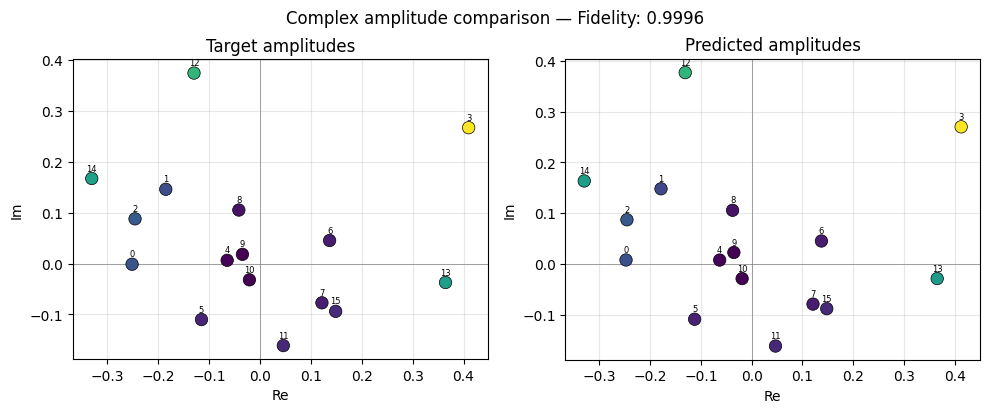

In [11]:
best_idx = sorted_idx[-1]
pred_c = pred_states_complex[best_idx]
target_c = target_states_complex[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, title in zip(axes, [target_c, pred_c], ["Target", "Predicted"]):
    ax.scatter(data.real, data.imag, c=np.abs(data) ** 2, cmap="viridis",
               s=80, edgecolors="black", linewidths=0.5, zorder=3)
    for k in range(state_dim):
        ax.annotate(f"{k}", (data[k].real, data[k].imag),
                    fontsize=6, ha="center", va="bottom", textcoords="offset points",
                    xytext=(0, 4))
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("Re")
    ax.set_ylabel("Im")
    ax.set_title(f"{title} amplitudes")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Complex amplitude comparison — Fidelity: {fidelities[best_idx]:.4f}", fontsize=12)
plt.tight_layout()
plt.show()

### 6.5 Summary

| Metric | Value |
|--------|-------|
| Architecture | MLP (8 → 64 → 64 → 16) + 4-qubit PQC (2 layers) |
| Training | 80 epochs, Adam (lr=0.001), MSE on state vectors |
| Teacher | Angle embedding + fixed random ansatz |
| State dimension | 16 complex amplitudes (4 qubits) |
| Final train MSE | 0.000068 |
| Final test MSE | 0.000146 |
| Mean test fidelity | 0.9951 (median 0.9975, min 0.9443) |

The MLP learns to map classical input vectors to PQC parameters that produce quantum states closely matching the teacher circuit's output. The MSE loss on real/imaginary components provides smooth gradients through the PQC via PennyLane's backprop interface, enabling end-to-end training of the hybrid classical-quantum pipeline.